## FRESEAN using SVD 
**Author:** Anjali Krishna, University of Delaware, 2026.

**AI use disclosure:** Claude (Anthropic) Opus models 4.6 and 4.7 were used to help clean up portions of this script. 
All AI-assisted code has been read, annotated manually, checked, and vetted by the author, and outputs were verified against known results before use.

In [18]:
import urllib.request
import numpy as np
import MDAnalysis as mda
import matplotlib.pyplot as plt

from MDAnalysis.analysis.dihedrals import Dihedral
from MDAnalysis.analysis.rms import rmsd

# Custom modules from the FRESEAN tutorial repo
import unwrap as pbc
import align as fit
import sys
import os

# drop any already-loaded wrong modules so the re-import takes the local files
for m in ("unwrap", "align", "graphics"):
    sys.modules.pop(m, None)

## Input Files

This notebook has been tested here on the 66-aa long Ala dipeptide.

In [2]:
# Input files
DATA_DIR = "data/MD-water-300K"
TOP = os.path.join(DATA_DIR, "topol.tpr")
TRR = os.path.join(DATA_DIR, "traj.trr")

TOP_URL = "https://www.dropbox.com/scl/fi/aydgkxfbtbeif7j7ptr5o/topol.tpr?rlkey=g4bztzt95dt402spumdxmz66n&dl=1"
TRR_URL = "https://www.dropbox.com/scl/fi/m0dlzyeaijw48wj8gky18/traj.trr?rlkey=gggwkd2e9rfwv8or13qgo3ulq&dl=1"

#Output directories
OUTDIR = "fresean_svd_ala_out"
FFT_DIR = os.path.join(OUTDIR, "block_ffts")
MODES_DIR = os.path.join(OUTDIR, "modes_by_bin")
PLOTS_DIR = os.path.join(OUTDIR, "plots")

SEL_STR = "all"
dt_ps = 0.004   # toy traj saved every 0.004 ps

# use only a single-conformation segment selected by phi/psi
USE_CONFORMATION_SEGMENT = True

# If selection segment is too short, set this False OR reduce N.

## Download inputs + load Universe

In [3]:
def download_if_needed(filename, url):
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    if not os.path.exists(filename):
        print(f"{filename} not found. Downloading from {url} ...")
        urllib.request.urlretrieve(url, filename)
        print(f"Downloaded {filename}.")

download_if_needed(TOP, TOP_URL)
download_if_needed(TRR, TRR_URL)

u = mda.Universe(TOP, TRR)
sel = u.select_atoms(SEL_STR)

print("nAtoms =", sel.n_atoms)                    # number of atoms selected
print("nDOF    =", 3 * sel.n_atoms)                # degrees of freedom = 3 per atom (x, y, z)
print("nFrames =", len(u.trajectory))              # total frames in the trajectory
print("dt_ps   =", dt_ps)




nAtoms  = 22
nDOF    = 66
nFrames = 250001
dt_ps   = 0.004


### **Ramachandran angle analysis**   (from original tutorial)

The conformations of alanine dipeptide can be characterized by its two peptide backbone dihedral angles $\phi$ and $\psi$ (ignoring methyl group rotations). We first analyze the fluctuations of $\phi$ and $\psi$ in the trajectory (this should take about 1 min). 

In [4]:
phi = Dihedral([sel.residues[1].phi_selection()]).run()
psi = Dihedral([sel.residues[1].psi_selection()]).run()

The following distribution gives us an idea on preferred conformations of the peptide and allows us to select a range of values that correspond to our target conformation.

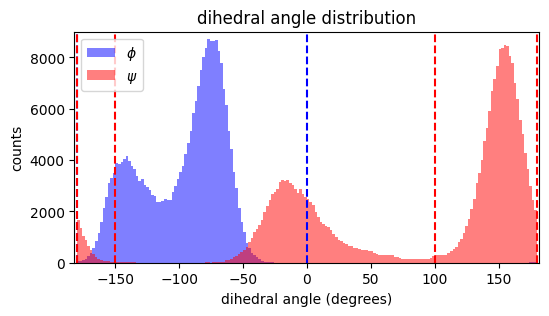

In [5]:
plt.figure(figsize=(6, 3))
plt.hist(phi.results.angles.T[0], bins=180, color='blue', alpha=0.5, label=r"$\phi$")
plt.hist(psi.results.angles.T[0], bins=180, color='red', alpha=0.5, label=r"$\psi$")
plt.xlim(-182,182)
plt.ylim(0, 9000)
plt.xlabel('dihedral angle (degrees)')
plt.ylabel('counts')
plt.title('dihedral angle distribution')
plt.vlines(-180, 0, 9000, colors='blue', linestyles='dashed')
plt.vlines(0, 0, 9000, colors='blue', linestyles='dashed')
plt.vlines(-180, 0, 9000, colors='red', linestyles='dashed')
plt.vlines(-150, 0, 9000, colors='red', linestyles='dashed')
plt.vlines(100, 0, 9000, colors='red', linestyles='dashed')
plt.vlines(180, 0, 9000, colors='red', linestyles='dashed')
plt.legend()
plt.show()

As indicated above, we use the range [-180,0] for $\phi$ (all frames in our trajectory).
For $\psi$, we select the ranges [-180,-150] or [100,180] which are split by periodic boundary conditions. This is taken into account below. 

Now, we select a consecutive segment of our trajectory which describes fluctuations around a single conformation.

In [6]:
trajIndices = np.arange(len(u.trajectory), dtype=int)   # default: use every frame

def longest_consecutive_indices(array1, lim1, array2, lim2, lim1alt=None, lim2alt=None):
    # array1, array2 = phi, psi time series ; lim* = allowed ranges (a box in phi/psi space)
    # the optional *alt ranges let a basin wrap across the +/-180 degree seam
    if lim1alt is None and lim2alt is None:                     # simple box, no wrapping
        mask = (array1 >= lim1[0]) & (array1 <= lim1[1]) & (array2 >= lim2[0]) & (array2 <= lim2[1])
    elif lim1alt is None:                                       # psi wraps, phi does not
        mask = (array1 >= lim1[0]) & (array1 <= lim1[1]) & (
            ((array2 >= lim2[0]) & (array2 <= lim2[1])) | ((array2 >= lim2alt[0]) & (array2 <= lim2alt[1]))
        )
    elif lim2alt is None:                                       # phi wraps, psi does not
        mask = (((array1 >= lim1[0]) & (array1 <= lim1[1])) | ((array1 >= lim1alt[0]) & (array1 <= lim1alt[1]))) & (
            (array2 >= lim2[0]) & (array2 <= lim2[1])
        )
    else:                                                       # both wrap
        mask = (
            (((array1 >= lim1[0]) & (array1 <= lim1[1])) | ((array1 >= lim1alt[0]) & (array1 <= lim1alt[1])))
            & (((array2 >= lim2[0]) & (array2 <= lim2[1])) | ((array2 >= lim2alt[0]) & (array2 <= lim2alt[1])))
        )

    # Walk the boolean mask and remember the LONGEST run of consecutive True values:
    max_len = 0;  max_start = -1                    # best run found so far
    current_len = 0;  current_start = -1            # run we are currently counting
    for i, ok in enumerate(mask):                   # scan frame by frame
        if ok:                                      # inside the basin
            if current_len == 0:                    # this frame starts a new run
                current_start = i
            current_len += 1                        # extend the current run
            if current_len > max_len:               # is this the longest so far
                max_len = current_len
                max_start = current_start
        else:                                       # left the basin, reset the counter
            current_len = 0
    if max_len == 0:                                # never inside the basin
        return None
    return np.arange(max_start, max_start + max_len, dtype=int)   # the winning frame indices

if USE_CONFORMATION_SEGMENT:
    phi = Dihedral([sel.residues[1].phi_selection()]).run()      # phi(t) of the central residue
    psi = Dihedral([sel.residues[1].psi_selection()]).run()      # psi(t) of the central residue

    trajIndices = longest_consecutive_indices(                   # longest single-basin stretch
        phi.results.angles.T[0], [-180, 0],                      # phi allowed range
        psi.results.angles.T[0], [100, 180],                     # psi main range
        lim2alt=[-180, -150]                                     # psi also allowed here (wrap)
    )
    if trajIndices is None:
        raise RuntimeError("No consecutive conformational segment found. Set USE_CONFORMATION_SEGMENT=False.")
    print(f"Basin segment length: {len(trajIndices)} frames = {len(trajIndices) * dt_ps:.3f} ps")
else:
    print("Using the FULL trajectory (no basin filtering).")



Basin segment length: 16734 frames = 66.936 ps


## Configuration for the modified FRESEAN approach

In [7]:
#CONF

# Windowing
use_hann = True
overlap_frac = 0.75

#Note:  Overlap changes how many blocks can be cut from the same trajectory. First, the Hann window wastes the edges of each block. It fades to near-zero at both ends, so frames near a block's start and end barely count. Overlap fixes this.
#Second, more blocks mean more samples to build the modes from, and a better mode decomposition. Overlapping at 75% gives about 4 times as many blocks from the same data.
#Hann windows shifted by N/4 add up to a flat weight across the trajectory, so no frame is over- or under-counted. Beyond that, overlapping blocks start repeating the same data.

# FFT window length (frames)
# 4096 --> 16.384 ps window --> df ~ 0.061 ps^-1 (~2.0 cm^-1)
N = 4096

# Modes to keep per frequency bin
n_modes_keep = 7 #max would be = no of blocks


## Build the unwrap and align objects

- `unwrap` removes periodic-boundary jumps so an atom never teleports across the box.
- `align` superimposes every frame onto a reference structure. **`rotVel=1` is the critical flag**: when we rotate coordinates we must rotate the velocity vectors the same way. If we do not, the velocity correlations that FRESEAN is built on are corrupted.

We use the first frame of the chosen basin as the alignment reference.

In [8]:
for d in (OUTDIR, FFT_DIR, MODES_DIR, PLOTS_DIR):  
    os.makedirs(d, exist_ok=True)
print("Output folders ready under:", OUTDIR)

unwrap = pbc.unwrap(u)                             # unwrapper bound to our Universe

u.trajectory[int(trajIndices[0])]                  # jump to the FIRST frame of the basin segment
unwrap.single_frame()                              

ref_pos = sel.positions.copy()                     
align = fit.align(                                  
    u,                                             
    sel,                                           
    rotVel=1,                                       #   rotate velocities together with coordinates (critical)
    placeCOMInBox=0,                               #   do not re-wrap the centre of mass
    altRefPos=ref_pos                             
)
print("unwrap + align constructed (velocities rotated with rotVel=1)")

Output folders ready under: fresean_svd_ala_out
unwrap + align constructed (velocities rotated with rotVel=1)


## Build the time windows and the frequency axis

`make_windows` produces a list of index arrays, one per block. With 75 percent overlap each window slides forward by `N/4` frames, so neighbouring blocks share most of their data. More blocks means better averaging in the VDoS and the modes.

`np.fft.rfftfreq` gives the one-sided frequency grid (0 up to the Nyquist frequency) that matches `np.fft.rfft`.

In [9]:
def make_windows(n_frames_local, N, overlap_frac):
    step = int(round(N * (1.0 - overlap_frac)))         
    step = max(1, step)                                 # never zero
    starts = list(range(0, n_frames_local - N + 1, step))   # start index of every full-length window
    return [np.arange(s, s + N, dtype=int) for s in starts] # one index array per block

n_frames_local = len(trajIndices)                   # frames available in the basin segment
windows = make_windows(n_frames_local, N, overlap_frac)
nBlocks = len(windows)                              # number of overlapping blocks we will FFT

T_ps      = N * dt_ps                               # window length in ps
df_ps1    = 1.0 / T_ps                              # frequency resolution in ps^-1
f_nyq_ps1 = 1.0 / (2.0 * dt_ps)                     # highest resolvable frequency (Nyquist)

freqs_ps1 = np.fft.rfftfreq(N, d=dt_ps)             # one-sided frequency grid, ps^-1
nBins = len(freqs_ps1)                              # number of frequency bins

print(f"N={N} frames which is T={T_ps:.3f} ps per window")
print(f"df = {df_ps1:.6f} ps^-1  ({df_ps1 * 33.3564095:.3f} cm^-1)")
print(f"Nyquist= {f_nyq_ps1:.3f} ps^-1")
print("nBins=", nBins)
print("nBlocks=", nBlocks)
if nBlocks < n_modes_keep:                          # you cannot have more modes than blocks
    print(f"NOTE: only {nBlocks} blocks, so at most {nBlocks} modes exist per bin (n_modes_keep={n_modes_keep}).")


N=4096 frames  which is  T=16.384 ps per window
df = 0.061035 ps^-1  (2.036 cm^-1)
Nyquist = 125.000 ps^-1
nBins= 2049
nBlocks= 13


## Function to turn frame into a mass-weighted velocity vector

For each frame build one flat vector: `[sqrt(m1)*vx1, sqrt(m1)*vy1, sqrt(m1)*vz1, sqrt(m2)*vx2, ...]`, length `nDOF`.

The steps per frame are always: load the frame, unwrap it, align it (which rotates the velocities), then multiply by `sqrt(mass)` and flatten.


In [10]:
sqrt_m = np.sqrt(sel.masses).astype(np.float32)[:, None]   # column of sqrt(mass), shape (nAtoms, 1)
nAtoms = sel.n_atoms                                # atom count
nDOF   = 3 * nAtoms                                 # length of each velocity vector

def get_massweighted_vel_vector_for_local_frame(local_idx):
    frame_idx = int(trajIndices[local_idx])         # map "position within segment" -> real frame number
    u.trajectory[frame_idx]                         # load that frame (coordinates + velocities)
    unwrap.single_frame()                           # fix periodic-boundary jumps
    align.single_frame()                            # rotate coords AND velocities onto the reference

    v = sel.velocities.astype(np.float32, copy=False)   # (nAtoms, 3) velocities from the TRR
    v_mw = v * sqrt_m                               # multiply each atom velocity by sqrt(mass)
    return v_mw.reshape(-1)                         # flatten to a length-nDOF vector

x0 = get_massweighted_vel_vector_for_local_frame(0) # quick test on the first frame
print("velocity vector shape:", x0.shape, "dtype:", x0.dtype)
print("expected nDOF:", nDOF)


velocity vector shape: (66,) dtype: float32
expected nDOF        : 66


## PASS A: FFT each block, save to disk, accumulate the VDoS

For every block:
1. stack its `N` mass-weighted velocity vectors into a matrix (`N x nDOF`),
2. multiply each time step by the Hann window,
3. FFT along the **time** axis to get `Xf` (`nBins x nDOF`), the velocity spectrum,
4. add `|Xf|^2` summed over DOF into the running VDoS,
5. save `Xf` to disk so PASS B can reuse it.

Saving each block to disk is what keeps memory flat when this is scaled to a big system.

In [11]:
def passA_write_block_ffts_and_vdos(overwrite=False):
    # pick the window shape (one number per time step, length N)
    if use_hann:
        w = np.hanning(N).astype(np.float32)     # Hann: fades in at the start, out at the end
    else:
        w = np.ones(N, dtype=np.float32)         # flat: every frame weighted equally (no taper)

    vdos_acc = np.zeros(nBins, dtype=np.float64) # running total of power at each frequency, summed over all blocks

    for b, win in enumerate(windows):            # b = block number, win = its frame indices
        outpath = os.path.join(FFT_DIR, f"block_{b:04d}.npy")   

        # CASE 1: we already computed this block on a previous run
        if (not overwrite) and os.path.exists(outpath):
            Xf = np.load(outpath, mmap_mode="r")                
            power = np.sum(np.abs(Xf)**2, axis=1, dtype=np.float64)   # |Xf|^2 summed over all DOF => power per frequency
            vdos_acc += power                                   

        # CASE 2: this block has not been computed yet 
        else:
            # build the block: one row per time step, one column per degree of freedom
            X = np.empty((N, nDOF), dtype=np.float32)          
            for ti, local_idx in enumerate(win):                # ti = row (time step), local_idx = which frame
                X[ti, :] = get_massweighted_vel_vector_for_local_frame(int(local_idx))  

            # apply the Hann window along time
            X *= w[:, None]                                    

            # FFT down the time axis: velocity-vs-time becomes velocity-vs-frequency
            Xf = np.fft.rfft(X, axis=0).astype(np.complex64, copy=False)   # shape (nBins, nDOF)

            # add this block's power to the running VDoS
            power = np.sum(np.abs(Xf)**2, axis=1, dtype=np.float64)        # power per frequency
            vdos_acc += power

            # save the spectrum so PASS B can reuse it, then free the memory
            np.save(outpath, Xf)                               # write Xf to disk
            del X, Xf                                          # drop these big arrays before the next block

        # print progress
        if (b + 1) % max(1, nBlocks // 5) == 0:                # every ~20% of the blocks
            print(f"PASS A: block {b + 1}/{nBlocks} done")

    # average the summed power over the number of blocks -> the raw VDoS
    return vdos_acc / float(nBlocks)


# run
print("Starting PASS A ...")
vdos = passA_write_block_ffts_and_vdos(overwrite=False)        # set overwrite=True to force a full recompute

# save 
np.save(os.path.join(OUTDIR, "freqs_ps1.npy"), freqs_ps1)     # x-axis: frequencies in ps^-1
np.save(os.path.join(OUTDIR, "vdos.npy"), vdos)               # y-axis: raw (un-normalized) VDoS
print("Saved freqs_ps1.npy and vdos.npy")

#monitor("after PASS A")                                        # report memory/CPU after this pass

Starting PASS A ...
PASS A: block 2/13 done
PASS A: block 4/13 done
PASS A: block 6/13 done
PASS A: block 8/13 done
PASS A: block 10/13 done
PASS A: block 12/13 done
Saved freqs_ps1.npy and vdos.npy


##### Estimate temperature from the velocities

We need `T` to normalise the VDoS against equipartition (each degree of freedom carries `1/2 kB T`). Temperature comes straight from kinetic energy: `<KE> = (nDOF/2) kB T`.

This function samples the whole trajectory (every 5th frame) rather than just the basin segment.

In [12]:
def estimate_T_from_trr(sample_stride=5):
    kB_md = 0.8314472                               # Boltzmann constant in amu*A^2/ps^2/K (MD units)
    K_acc = 0.0                                     # running sum of kinetic energy
    n_used = 0                                      # number of frames sampled

    for i, ts in enumerate(u.trajectory):           # walk the WHOLE trajectory
        if i % sample_stride != 0:                  # keep only every 5th frame (speed)
            continue
        v = sel.velocities                          # (nAtoms, 3)
        m = sel.masses[:, None]                     # (nAtoms, 1)
        K_frame = 0.5 * np.sum(m * v * v)           # kinetic energy of this frame
        K_acc += K_frame
        n_used += 1

    K_avg = K_acc / max(n_used, 1)                  # average kinetic energy
    nDOF_local = 3 * sel.n_atoms
    T_est = (2.0 * K_avg) / (nDOF_local * kB_md)    # invert equipartition to get T
    return T_est, K_avg, n_used

# NOTE: this leaves the trajectory pointer at the last frame. Harmless here because every later
# step re-seeks the exact frame it needs.
T_est, K_avg, n_used = estimate_T_from_trr(sample_stride=5)
print(f"T_est = {T_est:.2f} K   (from {n_used} sampled frames)")
print(f"K_avg = {K_avg:.4e}")

T_est = 299.66 K   (from 50001 sampled frames)
K_avg = 8.2220e+03


#### Normalise the VDoS to physical units

The raw VDoS has an arbitrary scale. Rescaling ensures its integrated area matches the equipartition target `nDOF * kB * T`, then convert to the FRESEAN velocity-spectrum convention (divide by the window time, factor `0.5`).

The `area_proxy` line accounts for the one-sided `rfft`: the DC bin is counted once, every other bin is counted twice (it stands in for its negative-frequency mirror).

In [22]:
kB_md = 0.8314472                               
nDOF  = 3 * sel.n_atoms

# One-sided rfft area: DC once, all other bins twice (mirror of the negative frequencies):
area_proxy = vdos[0] + 2.0 * np.sum(vdos[1:])   # "area" under the raw one-sided spectrum
target     = nDOF * kB_md * T_est               # equipartition target area
vdos_kbt   = vdos * (target / area_proxy)       # rescale the raw spectrum to hit the target

T_ps = N * dt_ps                                # window time (for the estimator prefactor)
vdos_fresean_norm = (vdos_kbt / T_ps) * 0.5    # velocity-spectrum normalisation

print(f"area_proxy (raw) = {area_proxy:.6e}")
print(f"target (nDOF kB T) = {target:.6e}")
print(f"T_ps (window)= {T_ps:.6f} ps")
print(f"peak( = {vdos_fresean_norm.max():.6e}")

area_proxy (raw) = 1.035570e+11
target (nDOF kB T) = 1.644410e+04
T_ps (window)= 16.384000 ps
peak( = 1.900820e+00


### Plot total VDOS

We tried to match this to the plot in the original tutorial. We convert the frequency axis from `ps^-1` to `cm^-1` (`1 ps^-1 = 33.3564 cm^-1`), smooth with a Gaussian whose width is set in `cm^-1`, and show only the low-frequency region (`<= 200 cm^-1`). Output is SVG (vector).


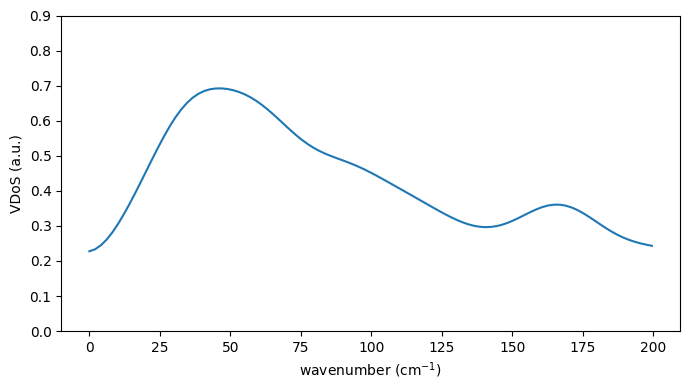

Saved fresean_svd_ala_out/plots/vdos_smooth.svg


In [23]:
from scipy.ndimage import gaussian_filter1d   # smoothing for a readable curve

ps1_to_cm1 = 33.3564095                         # 1 ps^-1 = 33.3564 cm^-1
freqs_cm1 = freqs_ps1 * ps1_to_cm1              # frequency axis in wavenumbers
df_cm1 = freqs_cm1[1] - freqs_cm1[0]            # bin spacing in cm^-1

sigma_cm1 = 10.0                                # smoothing width in cm^-1
sigma_bins = sigma_cm1 / df_cm1                 # convert that width into a number of bins

vdos_smooth = gaussian_filter1d(vdos_fresean_norm.astype(float), sigma=sigma_bins)  # smoothed VDoS

mask = freqs_cm1 <= 200.0                       # low-frequency window to display
plt.figure(figsize=(7, 4))
plt.plot(freqs_cm1[mask], vdos_smooth[mask])
plt.xlabel("wavenumber (cm$^{-1}$)")
plt.ylabel("VDoS (a.u.)")
plt.ylim(0, 0.9)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "vdos_smooth.svg"))   # vector output
plt.show()
print("Saved", os.path.join(PLOTS_DIR, "vdos_smooth.svg"))

## PASS B: frequency-resolved modes via the Gram matrix trick: 
At one frequency bin we build a matrix `F`:

- shape `nDOF x nBlocks` (rows = degrees of freedom, columns = blocks)
- each **column** is one block's velocity spectrum at this frequency

We want the dominant spatial patterns in those columns. Those patterns are the collective modes at this frequency, and mathematically they are the **left singular vectors of `F`**, the matrix called `U` in the SVD `F = U S Vh`.
So the entire goal of PASS B is: **get `U`**.

### Why the direct route might be memory heavy for a capsid

The textbook way to get `U` is to diagonalize `F Fh`. Its eigenvectors are exactly `U`. But ,

    F Fh  is  nDOF x nDOF
    capsid: 102,000 x 102,000  

### Solution:

`F` is skinny: far more rows than columns (100,000 rows, ~197 columns). A matrix with only `nBlocks` columns can hold at most `nBlocks` independent directions. So even though `U` lives in 100,000-dimensional space, **only `nBlocks` of its columns can be non-zero**. The rest are empty (zero singular value).


### The Gram matrix

Flip the product. Instead of `F Fh` (big), form `Fh F` (small):

    Fh F  is  nBlocks x nBlocks
    capsid: 197 x 197  ->  well under 1 MB

This is the **Gram matrix**, `G`. It is one matrix built from all blocks at once; it encodes how every block relates to every other block at this frequency. The blocks are its rows and columns (not one Gram matrix per block).

### Why flipping the order keeps the same modes

Write the SVD `F = U S Vh`. The two products share the same singular values `S`:

    F Fh = U S^2 Uh     eigenvectors = U (the modes)   ... huge
    Fh F = V S^2 Vh     eigenvectors = V               ... tiny

`U` and `V` are two halves of the same decomposition, linked through `F`. So if we get `V` and `S` from the small matrix, we have not lost `U`, we can rebuild it:

    U = F V / S

Take the original `F`, multiply by the small `V`, divide by the singular values, and get the modes. Cheap: `F V` is `F` times a `nBlocks`-column matrix, and the division is elementwise.


### One numerical caveat

 The strong low-frequency modes (most of the power) are unaffected. The weak, near-degenerate modes at the bottom of the ranked list come out noisier than a direct SVD would give. If you ever care about those weak modes specifically, use a direct SVD instead; for the dominant modes the Gram route is fine.

#### Quick sanity check: load one bin’s modes

In [20]:
k_star = 10                                     # any bin index you like for the check
modes_star = np.load(os.path.join(MODES_DIR, f"modes_k{k_star:04d}.npy"))  # (nEff, nDOF)
sing_star  = np.load(os.path.join(MODES_DIR, f"sing_k{k_star:04d}.npy"))   # (nEff,)

print("k*   =", k_star, " f* =", float(freqs_ps1[k_star]), "ps^-1")
print("modes_star:", modes_star.shape, modes_star.dtype)
print("sing_star :", sing_star.shape, sing_star.dtype)

# Load every block's FFT into RAM. 
Xf_blocks = np.empty((nBlocks, nBins, nDOF), dtype=np.complex64)
for b in range(nBlocks):
    Xf_blocks[b] = np.load(os.path.join(FFT_DIR, f"block_{b:04d}.npy"), mmap_mode="r")
print("Xf_blocks:", Xf_blocks.shape, Xf_blocks.dtype)


k*   = 10  f* = 0.6103515625 ps^-1
modes_star: (7, 66) complex64
sing_star : (7,) float64
Xf_blocks: (13, 2049, 66) complex64


## Mode contribution curves

Take the modes found at one frequency `k*` and ask how much of the motion at every frequency they explain. For each mode `m` and bin `k` we project the mode - i.e. take the inner product - onto every block's spectrum, square the overlap, and average over blocks.Squaring because inner product is a complex number.

In [21]:
def mode_contrib_curves_from_modes_at_kstar(modes_kstar, Xf_blocks):
    # a[m, b, k] = <mode_m , F_k(:, b)> = sum over DOF of conj(mode_m) * Xf_blocks[b, k, :]
    a = np.tensordot(np.conjugate(modes_kstar), Xf_blocks, axes=([1], [2]))   # (nModes, nBlocks, nBins)
    mode_curves = np.mean((a.real * a.real + a.imag * a.imag), axis=1)        # |overlap|^2 averaged over blocks -> (nModes, nBins)
    sum_modes = np.sum(mode_curves, axis=0)                                   # total across kept modes -> (nBins,)
    return mode_curves.astype(np.float64), sum_modes.astype(np.float64)

Using k*=25 -> f*=50.90 cm^-1
plotting 7 modes
scale factor raw -> fresean_style: 4.845969625547283e-09


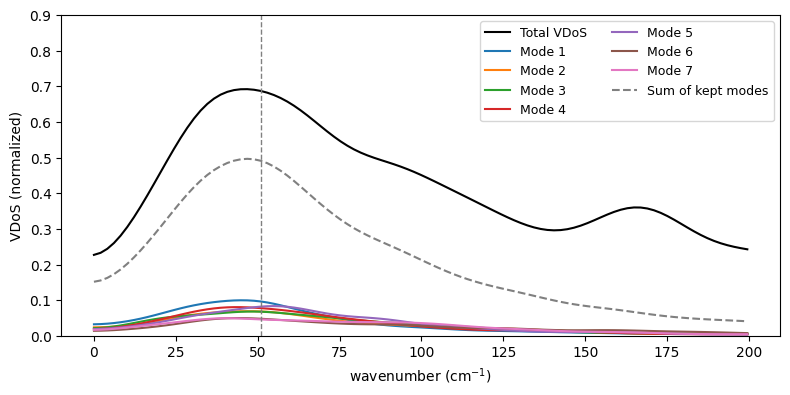

Saved fresean_svd_ala_out/plots/mode_contributions_k0025.svg
Fraction of the k* peak captured by the top 7 modes: 0.978


In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

target_cm1   = 50.0        # which peak (in cm^-1) to take the modes from
n_modes_plot = None        # None = use n_modes_keep
USE_SMOOTH   = True        # smooth curves for readability
sigma_cm1    = 10.0        # smoothing width (match the VDoS plot)
xmax_cm1     = 200.0       # x-axis limit

# frequency axis + display mask 
ps1_to_cm1 = 33.3564095
freqs_cm1 = freqs_ps1 * ps1_to_cm1
mask = freqs_cm1 <= xmax_cm1
df_cm1 = freqs_cm1[1] - freqs_cm1[0]
sigma_bins = sigma_cm1 / df_cm1

# total VDoS for the black background curve 
if USE_SMOOTH:
    vdos_plot = gaussian_filter1d(vdos_fresean_norm.astype(float), sigma=sigma_bins)
else:
    vdos_fresean_norm

#  reload block FFTs 
Xf_blocks = np.empty((nBlocks, nBins, nDOF), dtype=np.complex64)
for b in range(nBlocks):
    Xf_blocks[b] = np.load(os.path.join(FFT_DIR, f"block_{b:04d}.npy"), mmap_mode="r")

# find the bin nearest the requested peak 
k_star = int(np.argmin(np.abs(freqs_cm1 - target_cm1)))
f_star_cm1 = float(freqs_cm1[k_star])
print(f"Using k*={k_star} -> f*={f_star_cm1:.2f} cm^-1")

# load the modes computed at that bin
modes_star = np.load(os.path.join(MODES_DIR, f"modes_k{k_star:04d}.npy"))   # (nEff, nDOF)
if n_modes_plot is None:
    n_modes_plot = min(int(n_modes_keep), modes_star.shape[0])
else:
    n_modes_plot = min(int(n_modes_plot), modes_star.shape[0])
modes_star = modes_star[:n_modes_plot]             # keep the top few
print("plotting", n_modes_plot, "modes")

# project those modes onto every bin (unnormalised) 
a = np.tensordot(np.conjugate(modes_star), Xf_blocks, axes=([1], [2]))      # (nModes, nBlocks, nBins)
mode_curves_raw = np.mean((a.real * a.real + a.imag * a.imag), axis=1)      # (nModes, nBins)
sum_modes_raw   = np.sum(mode_curves_raw, axis=0)                           # (nBins,)

# put the mode curves on the SAME scale as vdos_fresean_norm
vdos_raw = np.load(os.path.join(OUTDIR, "vdos.npy"))                        # raw PASS A spectrum
lo, hi = 5, min(200, len(vdos_raw))                                        # ignore DC and the far tail
scalar = float(np.median(vdos_fresean_norm[lo:hi] / np.maximum(vdos_raw[lo:hi], 1e-30)))  # one scale factor
print("scale factor raw -> fresean_style:", scalar)
mode_curves = mode_curves_raw * scalar
sum_modes   = sum_modes_raw   * scalar

#  optional smoothing (same Gaussian as the VDoS) 
if USE_SMOOTH:
    mode_curves_s = np.vstack([gaussian_filter1d(mode_curves[m].astype(float), sigma=sigma_bins) for m in range(n_modes_plot)])
    sum_modes_s   = gaussian_filter1d(sum_modes.astype(float), sigma=sigma_bins)
else:
    mode_curves_s = mode_curves
    sum_modes_s   = sum_modes

# plot 
plt.figure(figsize=(8, 4))
plt.plot(freqs_cm1[mask], vdos_plot[mask], color="black", label="Total VDoS")   # background total
for m in range(n_modes_plot):
    plt.plot(freqs_cm1[mask], mode_curves_s[m, mask], label=f"Mode {m + 1}")     # each mode's curve
plt.plot(freqs_cm1[mask], sum_modes_s[mask], color="gray", linestyle="--", label="Sum of kept modes")
plt.axvline(f_star_cm1, color="gray", linestyle="--", linewidth=1)               # mark k*
plt.xlabel("wavenumber (cm$^{-1}$)")
plt.ylabel("VDoS (normalized)")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.ylim(0, 0.9)
plt.savefig(os.path.join(PLOTS_DIR, f"mode_contributions_k{k_star:04d}.svg"))
plt.show()
print("Saved", os.path.join(PLOTS_DIR, f"mode_contributions_k{k_star:04d}.svg"))

# how much of the peak do these modes capture?
frac = float(sum_modes[k_star] / max(vdos_fresean_norm[k_star], 1e-30))
print(f"Fraction of the k* peak captured by the top {n_modes_plot} modes: {frac:.3f}")


## Save results

In [25]:
np.savez(                                       # compact results bundle
    os.path.join(OUTDIR, "svd_results.npz"),
    freqs_cm1=freqs_cm1,                        # frequency axis in cm^-1
    vdos=vdos_fresean_norm,                    # normalised total VDoS
    mode_curves=mode_curves_s,                  # smoothed per-mode contribution curves
    sum_modes=sum_modes_s,                      # smoothed sum of kept modes
)
print("Saved svd_results.npz")

np.savez(                                       # verbose bundle that reproduces the exact plot
    os.path.join(OUTDIR, "svd_results_exact_plot.npz"),
    freqs_cm1=freqs_cm1,
    vdos_raw=vdos_fresean_style,
    vdos_smooth=vdos_smooth,
    mode_curves_raw=mode_curves,
    mode_curves_smooth=mode_curves_s,
    sum_modes_raw=sum_modes,
    sum_modes_smooth=sum_modes_s,
    target_cm1=target_cm1,
    k_star=k_star,
    f_star_cm1=f_star_cm1,
    n_modes_plot=n_modes_plot,
    sigma_cm1=sigma_cm1,
    use_smooth=USE_SMOOTH,
)
print("Saved svd_results_exact_plot.npz")
print("All done.")

Saved svd_results.npz
Saved svd_results_exact_plot.npz
All done.
